# Homework 2  

The goal of this assignment is experiment with classification pipelines (in this case, for instrument classification) using spectrograms.

In [1]:
# Set this yourself depending where you put the files
dataroot = "."
# On the autograder it should be here:
# dataroot = "."

In [2]:
# !pip install librosa
# !pip install torch
# !pip install glob
#!pip install numpy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as nnF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import librosa
import random
# import librosa.display
# import matplotlib.pyplot as plt
import glob

In [4]:
torch.use_deterministic_algorithms(True) # Try to make things less random, though not required

In [5]:
audio_paths = glob.glob(dataroot + "/nsynth_subset/*.wav")
random.seed(0)
random.shuffle(audio_paths)

In [6]:
if not len(audio_paths):
    print("You probably need to set the dataroot folder correctly")

In [7]:
SAMPLE_RATE = 8000 # Very low sample rate, just so things run quickly
N_MFCC = 13
INSTRUMENT_MAP = {'guitar': 0, 'vocal': 1} # Only two classes (also so that things run quickly)
NUM_CLASSES = len(INSTRUMENT_MAP)

# If we used all the classes we would have:
# INSTRUMENT_MAP = {
#     'bass': 0, 'brass': 1, 'flute': 2, 'guitar': 3,
#     'keyboard': 4, 'mallet': 5, 'organ': 6, 'reed': 7,
#     'string': 8, 'synth_lead': 9, 'vocal': 10
# }

1. Extract prediction labels and construct waveforms

`extract_waveform()`

**Inputs**
- `path`: A string that represents a path to the wav file

**Outputs**
- `waveform`: an array containing the waveform; use librosa.load, remember to set the sample rate correctly

`extract_label()`

**Inputs**
- `path'

**Outputs**
- `label`: A integer that represents the label of the path (hint: look at the filename and make use of `INSTRUMENT_MAP`)

In [24]:
def extract_waveform(path):
    # Your code here
    waveform, sr = librosa.load(path, sr = SAMPLE_RATE)
    return waveform

In [38]:
audio_paths

['./nsynth_subset/guitar_acoustic_021-031-025.wav',
 './nsynth_subset/guitar_acoustic_015-043-050.wav',
 './nsynth_subset/vocal_acoustic_000-053-127.wav',
 './nsynth_subset/vocal_synthetic_003-052-127.wav',
 './nsynth_subset/guitar_electronic_022-078-050.wav',
 './nsynth_subset/guitar_acoustic_010-025-050.wav',
 './nsynth_subset/guitar_acoustic_021-091-050.wav',
 './nsynth_subset/guitar_acoustic_030-041-075.wav',
 './nsynth_subset/guitar_acoustic_010-053-127.wav',
 './nsynth_subset/vocal_synthetic_003-043-050.wav',
 './nsynth_subset/vocal_synthetic_003-023-075.wav',
 './nsynth_subset/vocal_synthetic_003-021-100.wav',
 './nsynth_subset/guitar_acoustic_021-105-100.wav',
 './nsynth_subset/vocal_acoustic_000-055-075.wav',
 './nsynth_subset/guitar_acoustic_010-054-050.wav',
 './nsynth_subset/vocal_synthetic_003-099-127.wav',
 './nsynth_subset/guitar_acoustic_014-064-050.wav',
 './nsynth_subset/vocal_synthetic_003-048-100.wav',
 './nsynth_subset/guitar_acoustic_030-052-100.wav',
 './nsynth_s

In [41]:
def extract_label(path):
    # Your code here
    instrument = path.split("/")[-1].split("_")[0]
    label = INSTRUMENT_MAP[instrument]

    return label

In [42]:
waveforms = [extract_waveform(p) for p in audio_paths]
labels = [extract_label(p) for p in audio_paths]

extracted_waveform.shape=(32000,)


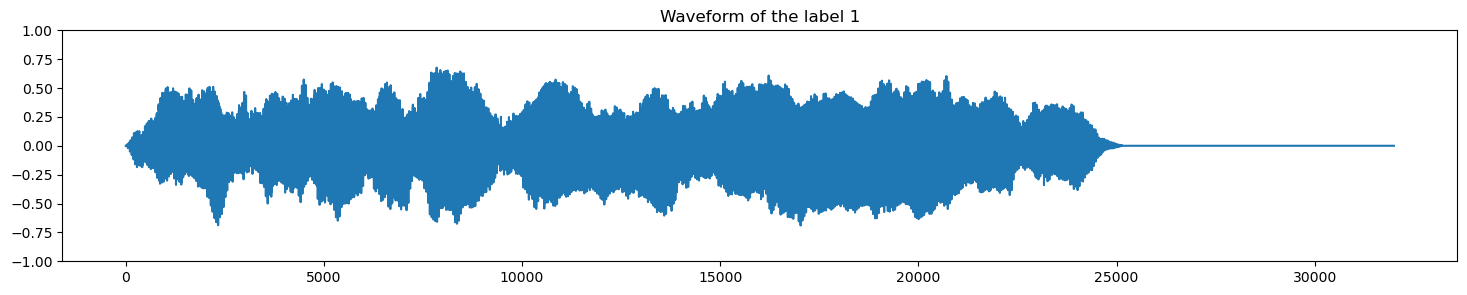

In [ ]:
# def visualize(extracted_waveform, label):  
#     print(f'{extracted_waveform.shape=}')

#     plt.figure(figsize=(18, 3)) # plot using matplotlib
#     plt.title(f'Waveform of the label {label}')
#     plt.plot(extracted_waveform)
#     plt.ylim([-1, 1])

# visualize(waveforms[2], labels[2])

A few simple classifiers are provided. You don't need to modify these (though the autograder will *probably* work if you'd like to experiment with architectural changes)

In [47]:
class MLPClassifier(nn.Module):
    def __init__(self):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(2 * N_MFCC, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, NUM_CLASSES)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [48]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(64, NUM_CLASSES)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool1(nnF.relu(self.bn1(self.conv1(x))))
        x = self.pool2(nnF.relu(self.bn2(self.conv2(x))))
        x = self.pool3(nnF.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

2. Extract mfcc features

`extract_mfcc()`

**Inputs**
- `waveform`: an array containing the waveform

**Outputs**
- `feature`: a PyTorch float tensor that represents a concatenation of 13 mean values and 13 standard deviation values

**Process**
- Extract feature using `librosa.feature.mfcc`; remember to set the sample rate and n_mfcc
- Compute 13 mean and 13 standard deviation values
- Concatenate them together

In [ ]:
def extract_mfcc(w):
    # Your code here:
    # load using librosa.feature.mfcc
    # extract mean and std
    mfcc = librosa.feature.mfcc(y=w, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
    mean = np.mean(mfcc, axis=1)
    std = np.std(mfcc, axis=1)

    features = np.concatenate((mean, std))

    # concatenate
    return torch.FloatTensor(features)

In [65]:
extract_mfcc(waveforms[0])

tensor([-323.3484,  128.1266,   24.1387,   18.7368,   11.3390,    2.5830,
           7.2964,   14.3559,    6.7855,    1.1589,    3.4064,   10.2506,
          13.9054,  111.8754,   70.1890,   30.2898,   16.3662,    8.1358,
           4.9814,    5.7264,    8.1223,    4.0675,    2.3386,    3.1114,
           5.3953,    7.3117])

## Note:

The autograder will test that your MFCC features are correct, and it will *also* use them within an ML pipeline. The test_suite can be used to run the full pipeline after you've implemented these functions. If you've implemented your features correctly this should "just work" and you'll be able to upload the trained; this is mostly here just so that you can see how the full pipeline works (which will be useful when you develop your own pipelines for Assignment 1)

3. Extract spectrograms

`extract_spec()`

**Inputs**
- `waveform`: an array containing the waveform

**Outputs**
- `feature`: a PyTorch float tensor that contains a spectrogram

**Process**
- apply STFT to the given waveform
- square the absolute values of the complex numbers from the STFT

In [ ]:
def extract_spec(w):
    # Your code here
    n_fft = 2048 # STFT parameter; higher n_fft = higher frequency resolution
    hop_length = 512 # STFT parameter; smaller hop_length = higher time resolution

    # load
    stft = librosa.stft(w, n_fft=n_fft, hop_length=hop_length)

    # take squared absolute values
    spec = torch.FloatTensor(np.abs(stft) ** 2)

    return spec

In [74]:
extract_spec(waveforms[0]).shape

torch.Size([513, 63])

4. Extract mel-spectrograms

`extract_mel()`

**Inputs**
- `waveform`: an array containing the waveform
- `n_mels`: number of mel bands
- `hop_length`: hop length

**Outputs**
- `feature`: A PyTorch Float Tensor that contains a mel-spectrogram

**Process**
- generate melspectrograms with `librosa.feature.melspectrogram`; make sure to se the sample rate, n_mels, and hop_length
- convert them to decibel units with `librosa.power_to_db`
- normalize values to be in the range 0 to 1

In [ ]:
def extract_mel(w, n_mels = 128, hop_length = 512):
    # Your code here
    # load and convert to db
    log_melgram = librosa.power_to_db(
    np.abs(
        librosa.feature.melspectrogram(y=w, sr=SAMPLE_RATE, hop_length=hop_length,n_mels=n_mels)
        )
    )

    # normalize
    mel_spec_db = (log_melgram - np.min(log_melgram)) / (np.max(log_melgram) - np.min(log_melgram))

    return torch.FloatTensor(mel_spec_db)

5. Extract constant-Q transform

`extract_q()`

**Inputs**
- `waveform`: an array containing the waveform

**Outputs**
- `feature`: A PyTorch Float Tensor that contains a constant-Q transform

**Process**
- generate constant-Q transform with `librosa.cqt`; this one will need a higher sample rate (use 16000) to work

In [ ]:
def extract_q(w):
    # Your code here
    log_cqt = np.abs(
            librosa.cqt(y=w, sr=16000, hop_length=512, n_bins=84, bins_per_octave=12, fmin=librosa.note_to_hz('C1'))
            )
        
    return torch.FloatTensor(log_cqt)

6. Pitch shift

`pitch_shift()`

**Inputs**
- `waveform`: an array containing the waveform
- `n`: number of semitones to shift by (integer, can be positive or negative)

**Outputs**
- `waveform`: a pitch-shifted waveform

**Process**
- use `librosa.effects.pitch_shift`

In [80]:
def pitch_shift(w, n):
    # Your code here
    y_shift = librosa.effects.pitch_shift(w, sr=SAMPLE_RATE, n_steps=n)

    return y_shift

In [81]:
# Code below augments the datasets

augmented_waveforms = []
augmented_labels = []

for w,y in zip(waveforms,labels):
    augmented_waveforms.append(w)
    augmented_waveforms.append(pitch_shift(w,1))
    augmented_waveforms.append(pitch_shift(w,-1))
    augmented_labels += [y,y,y]

7. Extend the model to work for four classes.

By making data augmentations, or modifying the model architecture, build a model with test accuracy > 0.93

In [82]:
INSTRUMENT_MAP_7 = {'guitar_acoustic': 0, 'guitar_electronic': 1, 'vocal_acoustic': 2, 'vocal_synthetic': 3}

In [83]:
NUM_CLASSES_7 = 4

In [ ]:
def extract_label_7(path):
    # Your code here
    instrument = path.split("/")[-1].split("_")[0]
    type = path.split("/")[-1].split("_")[1]

    combined = instrument + "_" + type
    label = INSTRUMENT_MAP_7[combined]

    return label

In [98]:
# Select which feature function to use.
# Can be one of the existing ones (e.g. extract_mfcc), or you can write a new one.
feature_func_7 = extract_mel

In [ ]:
labels_7 = [extract_label_7(p) for p in audio_paths]

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.AdaptiveAvgPool2d((1, 1))

        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool4 = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(128, 4)

    def forward(self, x):
        x = x.unsqueeze(1) 
        x = self.pool1(nnF.relu(self.bn1(self.conv1(x))))
        x = self.pool2(nnF.relu(self.bn2(self.conv2(x))))
        x = self.pool3(nnF.relu(self.bn3(self.conv3(x))))
        x = self.pool4(nnF.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [ ]:
# Select which model to use.
# Can use an existing model (e.g. MLPClassifier) or modify it.
# Note that you'll need to copy and (slightly) modify the existing class to handle 4 labels.
model_7 = CNN()